In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import time  
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import GridSearchCV 
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics 
from jcopml.feature_importance import mean_score_decrease  


In [2]:
pd.set_option('display.max_columns',None)

In [3]:
print(pd.__version__)

2.3.0


In [4]:
path_1 = "https://raw.githubusercontent.com/brainspopper/dataset/main/FinanKu%20Data%20All.csv"
path_2 = "https://raw.githubusercontent.com/brainspopper/dataset/main/FinanKu%20Data%20Validasi.csv"
df_all = pd.read_csv(path_1)
df_val = pd.read_csv(path_2)

In [5]:
df1 = pd.read_csv (path_1)
df1.head()

,Customer ID,Branch Code,City,Age,Avg. Annual Income/Month,Balance Q1,NumOfProducts Q1,HasCrCard Q1,ActiveMember Q1,Balance Q2,NumOfProducts Q2,HasCrCard Q2,ActiveMember Q2,Balance Q3,NumOfProducts Q3,HasCrCard Q3,ActiveMember Q3,Balance Q4,NumOfProducts Q4,HasCrCard Q4,ActiveMember Q4,Unpaid Tagging
0,15565701,1001,Jakarta,29,33000000,0.0,1,1,1,0.0,1,1,0,0.00,1,1,0,1187036.18,1,1,1,1
1,15565878,1005,Jakarta,68,17000000,0.0,2,1,1,0.0,2,1,0,0.00,2,1,0,0.00,2,1,0,0
2,15566091,1009,Jakarta,25,12000000,0.0,2,1,0,0.0,2,1,0,0.00,2,1,0,1351820.24,2,1,1,0
3,15566292,1008,Jakarta,42,19000000,0.0,2,1,1,0.0,2,1,0,0.00,2,1,0,0.00,2,1,0,0
4,15566312,1009,Jakarta,43,29000000,0.0,2,1,0,0.0,2,1,0,678905.68,2,1,1,431190.68,2,1,1,0


In [6]:
df2 = pd.read_csv (path_1)
df2.head()

,Customer ID,Branch Code,City,Age,Avg. Annual Income/Month,Balance Q1,NumOfProducts Q1,HasCrCard Q1,ActiveMember Q1,Balance Q2,NumOfProducts Q2,HasCrCard Q2,ActiveMember Q2,Balance Q3,NumOfProducts Q3,HasCrCard Q3,ActiveMember Q3,Balance Q4,NumOfProducts Q4,HasCrCard Q4,ActiveMember Q4,Unpaid Tagging
0,15565701,1001,Jakarta,29,33000000,0.0,1,1,1,0.0,1,1,0,0.00,1,1,0,1187036.18,1,1,1,1
1,15565878,1005,Jakarta,68,17000000,0.0,2,1,1,0.0,2,1,0,0.00,2,1,0,0.00,2,1,0,0
2,15566091,1009,Jakarta,25,12000000,0.0,2,1,0,0.0,2,1,0,0.00,2,1,0,1351820.24,2,1,1,0
3,15566292,1008,Jakarta,42,19000000,0.0,2,1,1,0.0,2,1,0,0.00,2,1,0,0.00,2,1,0,0
4,15566312,1009,Jakarta,43,29000000,0.0,2,1,0,0.0,2,1,0,678905.68,2,1,1,431190.68,2,1,1,0


In [7]:
data1 = pd.DataFrame (
                     df_all.groupby(by=['City'])['Customer ID']
                        .count()
                        .sort_values(ascending=False)
                        .reset_index(name = 'Distribution by City')
                        )
data1

,City,Distribution by City
0,Surabaya,3767
1,Bandung,1898
2,Jakarta,1896


In [8]:
data2 = pd.DataFrame (
                     df_all [df_all ['Unpaid Tagging']==1].groupby(by=['City'])['Customer ID']
                        .count()
                        .sort_values(ascending=False)
                        .reset_index(name = 'Distribution by City')
                        )
data2

,City,Distribution by City
0,Surabaya,1033
1,Bandung,496
2,Jakarta,490


<Axes: title={'center': 'Cust. Distribution by Age'}, xlabel='Age', ylabel='# People'>

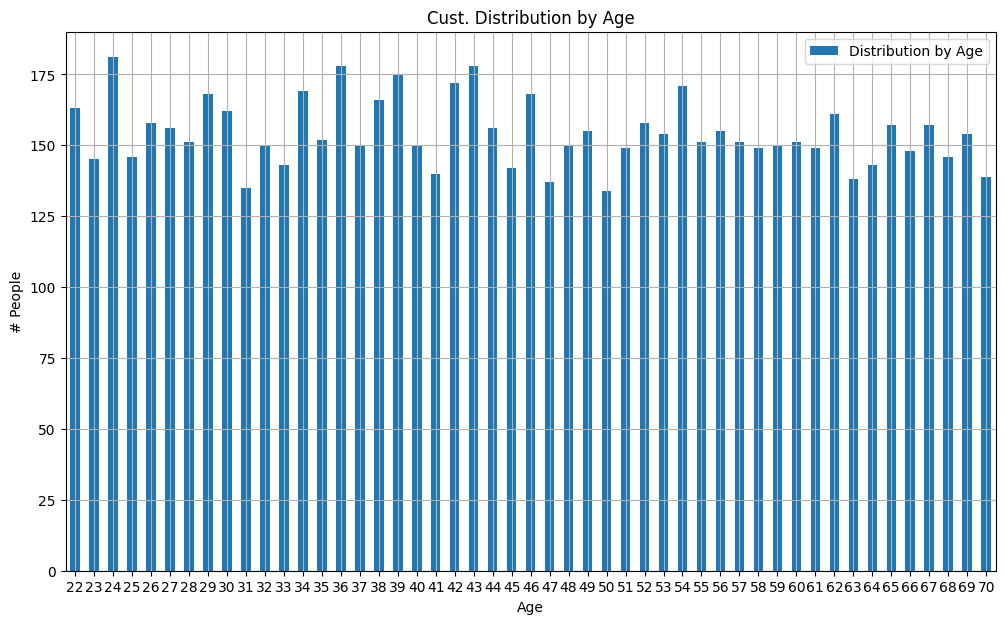

In [9]:
data3 = pd.DataFrame(\
                      #Mengelompokkan berdasarkan usia                      df_all.groupby(by=['Age'])['Customer ID']\
                       df_all.groupby(by=['Age'])['Customer ID']\
                      #Diagegatkan dengan menghitung jumlahnya (count)
                       .count()\
                      #reset nama header
                       .reset_index(name='Distribution by Age'))
data3.sort_values(\
                  by=['Age'], \
                  ascending=True, \
                  inplace=True)
data3.plot(x='Age',
          y=['Distribution by Age'],
          kind='bar',
          grid=True,
          xlabel='Age',
          ylabel='# People',
          figsize=(12,7),
          rot=0,
          title='Cust. Distribution by Age',
          table=False,
          secondary_y = False)

<Axes: title={'center': 'Unpaid Cust. Distribution by Age'}, xlabel='Age', ylabel='# People'>

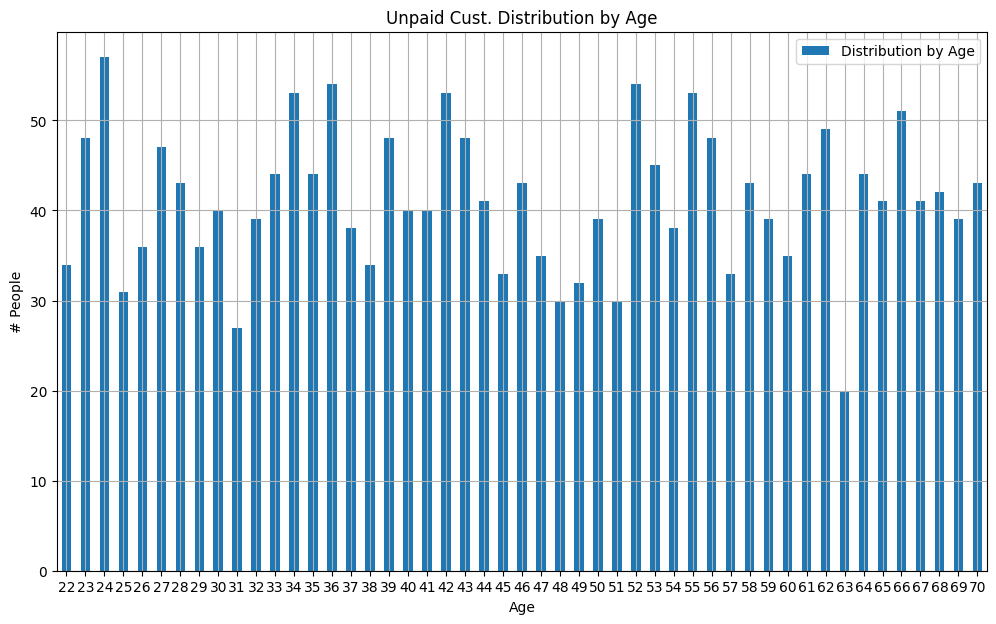

In [10]:
data4 = pd.DataFrame(\
                      #Mengelompokkan berdasarkan usia
                       df_all[df_all['Unpaid Tagging']==1].groupby(by=['Age'])['Customer ID']\
                      #Diagegatkan dengan menghitung jumlahnya (count)
                       .count()\
                      #reset nama header
                       .reset_index(name='Distribution by Age'))
data4.sort_values(\
                  by=['Age'], \
                  ascending=True, \
                  inplace=True)
data4.plot(x='Age',
          y=['Distribution by Age'],
          kind='bar',
          grid=True,
          xlabel='Age',
          ylabel='# People',
          figsize=(12,7),
          rot=0,
          title='Unpaid Cust. Distribution by Age',
          table=False,
          secondary_y = False)

In [11]:
df_checkbalance = df_all
df_checkbalance['Total Balance'] = df_checkbalance['Balance Q1'] + df_checkbalance['Balance Q2'] + df_checkbalance['Balance Q3'] + df_checkbalance['Balance Q4']
df_checkbalance['Avg Balance'] = (df_checkbalance['Balance Q1'] + df_checkbalance['Balance Q2'] + df_checkbalance['Balance Q3'] + df_checkbalance['Balance Q4'])/4

data5 = pd.DataFrame(\
                      df_checkbalance.groupby(by=['Unpaid Tagging'])['Total Balance']\
                      .mean()\
                      .reset_index(name='Avg Annual Balance'))
data5

,Unpaid Tagging,Avg Annual Balance
0,0,1.985924e+08
1,1,2.527238e+08


In [12]:
data6 = pd.DataFrame(\
                      df_checkbalance.groupby(by=['Unpaid Tagging'])['Avg Balance']\
                      .mean()\
                      .reset_index(name='Avg Quarterly Balance'))
data6

,Unpaid Tagging,Avg Quarterly Balance
0,0,4.964809e+07
1,1,6.318095e+07


In [13]:
df_checkbalance['Avg Product'] = (df_checkbalance['NumOfProducts Q1'] +
                                   df_checkbalance['NumOfProducts Q2'] +
                                   df_checkbalance['NumOfProducts Q3'] +
                                   df_checkbalance['NumOfProducts Q4'])/4
data7 = pd.DataFrame(\
                      df_checkbalance.groupby(by=['Unpaid Tagging'])['Avg Product']\
                      .mean()\
                      .reset_index(name='Avg Product Owned'))
data7

,Unpaid Tagging,Avg Product Owned
0,0,1.667223
1,1,1.609336


In [14]:
df_all = df_all.drop (columns=['Total Balance', 'Avg Balance', 'Avg Product'])

In [15]:
df_all.duplicated().sum()


np.int64(0)

In [16]:
df_all.isnull().sum()

Customer ID                 0
Branch Code                 0
City                        0
Age                         0
Avg. Annual Income/Month    0
Balance Q1                  0
NumOfProducts Q1            0
HasCrCard Q1                0
ActiveMember Q1             0
Balance Q2                  0
NumOfProducts Q2            0
HasCrCard Q2                0
ActiveMember Q2             0
Balance Q3                  0
NumOfProducts Q3            0
HasCrCard Q3                0
ActiveMember Q3             0
Balance Q4                  0
NumOfProducts Q4            0
HasCrCard Q4                0
ActiveMember Q4             0
Unpaid Tagging              0
dtype: int64

In [17]:
df1['Mean Balance'] = (df1['Balance Q1'] + df1['Balance Q2'] + df1['Balance Q3'] + df1['Balance Q4'])/4
df1['Delta Balance'] = df1['Balance Q4'] - df1['Balance Q1']
df1.head()

,Customer ID,Branch Code,City,Age,Avg. Annual Income/Month,Balance Q1,NumOfProducts Q1,HasCrCard Q1,ActiveMember Q1,Balance Q2,NumOfProducts Q2,HasCrCard Q2,ActiveMember Q2,Balance Q3,NumOfProducts Q3,HasCrCard Q3,ActiveMember Q3,Balance Q4,NumOfProducts Q4,HasCrCard Q4,ActiveMember Q4,Unpaid Tagging,Mean Balance,Delta Balance
0,15565701,1001,Jakarta,29,33000000,0.0,1,1,1,0.0,1,1,0,0.00,1,1,0,1187036.18,1,1,1,1,296759.045,1187036.18
1,15565878,1005,Jakarta,68,17000000,0.0,2,1,1,0.0,2,1,0,0.00,2,1,0,0.00,2,1,0,0,0.000,0.00
2,15566091,1009,Jakarta,25,12000000,0.0,2,1,0,0.0,2,1,0,0.00,2,1,0,1351820.24,2,1,1,0,337955.060,1351820.24
3,15566292,1008,Jakarta,42,19000000,0.0,2,1,1,0.0,2,1,0,0.00,2,1,0,0.00,2,1,0,0,0.000,0.00
4,15566312,1009,Jakarta,43,29000000,0.0,2,1,0,0.0,2,1,0,678905.68,2,1,1,431190.68,2,1,1,0,277524.090,431190.68


In [18]:
df2['Mean Balance']= (df2['Balance Q3'] + df2['Balance Q4'])/2
df2['Delta Balance'] = df2['Balance Q4'] - df2['Balance Q2']
df2.head()

,Customer ID,Branch Code,City,Age,Avg. Annual Income/Month,Balance Q1,NumOfProducts Q1,HasCrCard Q1,ActiveMember Q1,Balance Q2,NumOfProducts Q2,HasCrCard Q2,ActiveMember Q2,Balance Q3,NumOfProducts Q3,HasCrCard Q3,ActiveMember Q3,Balance Q4,NumOfProducts Q4,HasCrCard Q4,ActiveMember Q4,Unpaid Tagging,Mean Balance,Delta Balance
0,15565701,1001,Jakarta,29,33000000,0.0,1,1,1,0.0,1,1,0,0.00,1,1,0,1187036.18,1,1,1,1,593518.09,1187036.18
1,15565878,1005,Jakarta,68,17000000,0.0,2,1,1,0.0,2,1,0,0.00,2,1,0,0.00,2,1,0,0,0.00,0.00
2,15566091,1009,Jakarta,25,12000000,0.0,2,1,0,0.0,2,1,0,0.00,2,1,0,1351820.24,2,1,1,0,675910.12,1351820.24
3,15566292,1008,Jakarta,42,19000000,0.0,2,1,1,0.0,2,1,0,0.00,2,1,0,0.00,2,1,0,0,0.00,0.00
4,15566312,1009,Jakarta,43,29000000,0.0,2,1,0,0.0,2,1,0,678905.68,2,1,1,431190.68,2,1,1,0,555048.18,431190.68


In [19]:
df1['Diff PH'] = df1['NumOfProducts Q4'] - df1['NumOfProducts Q1']
df1.head()

,Customer ID,Branch Code,City,Age,Avg. Annual Income/Month,Balance Q1,NumOfProducts Q1,HasCrCard Q1,ActiveMember Q1,Balance Q2,NumOfProducts Q2,HasCrCard Q2,ActiveMember Q2,Balance Q3,NumOfProducts Q3,HasCrCard Q3,ActiveMember Q3,Balance Q4,NumOfProducts Q4,HasCrCard Q4,ActiveMember Q4,Unpaid Tagging,Mean Balance,Delta Balance,Diff PH
0,15565701,1001,Jakarta,29,33000000,0.0,1,1,1,0.0,1,1,0,0.00,1,1,0,1187036.18,1,1,1,1,296759.045,1187036.18,0
1,15565878,1005,Jakarta,68,17000000,0.0,2,1,1,0.0,2,1,0,0.00,2,1,0,0.00,2,1,0,0,0.000,0.00,0
2,15566091,1009,Jakarta,25,12000000,0.0,2,1,0,0.0,2,1,0,0.00,2,1,0,1351820.24,2,1,1,0,337955.060,1351820.24,0
3,15566292,1008,Jakarta,42,19000000,0.0,2,1,1,0.0,2,1,0,0.00,2,1,0,0.00,2,1,0,0,0.000,0.00,0
4,15566312,1009,Jakarta,43,29000000,0.0,2,1,0,0.0,2,1,0,678905.68,2,1,1,431190.68,2,1,1,0,277524.090,431190.68,0


In [20]:
df2['Diff PH'] = df2['NumOfProducts Q4'] - df2['NumOfProducts Q2']
df2.head()

,Customer ID,Branch Code,City,Age,Avg. Annual Income/Month,Balance Q1,NumOfProducts Q1,HasCrCard Q1,ActiveMember Q1,Balance Q2,NumOfProducts Q2,HasCrCard Q2,ActiveMember Q2,Balance Q3,NumOfProducts Q3,HasCrCard Q3,ActiveMember Q3,Balance Q4,NumOfProducts Q4,HasCrCard Q4,ActiveMember Q4,Unpaid Tagging,Mean Balance,Delta Balance,Diff PH
0,15565701,1001,Jakarta,29,33000000,0.0,1,1,1,0.0,1,1,0,0.00,1,1,0,1187036.18,1,1,1,1,593518.09,1187036.18,0
1,15565878,1005,Jakarta,68,17000000,0.0,2,1,1,0.0,2,1,0,0.00,2,1,0,0.00,2,1,0,0,0.00,0.00,0
2,15566091,1009,Jakarta,25,12000000,0.0,2,1,0,0.0,2,1,0,0.00,2,1,0,1351820.24,2,1,1,0,675910.12,1351820.24,0
3,15566292,1008,Jakarta,42,19000000,0.0,2,1,1,0.0,2,1,0,0.00,2,1,0,0.00,2,1,0,0,0.00,0.00,0
4,15566312,1009,Jakarta,43,29000000,0.0,2,1,0,0.0,2,1,0,678905.68,2,1,1,431190.68,2,1,1,0,555048.18,431190.68,0


In [21]:
def assign_cr1(row):
    if row['HasCrCard Q1'] == 1:
        return 12
    elif row['HasCrCard Q2'] == 1:
        return 9
    elif row['HasCrCard Q3'] == 1:
        return 6
    else:
        return 3

In [22]:
df1['Vintage_CR'] = df1.apply(assign_cr1, axis=1)


In [23]:
df1.head()

,Customer ID,Branch Code,City,Age,Avg. Annual Income/Month,Balance Q1,NumOfProducts Q1,HasCrCard Q1,ActiveMember Q1,Balance Q2,NumOfProducts Q2,HasCrCard Q2,ActiveMember Q2,Balance Q3,NumOfProducts Q3,HasCrCard Q3,ActiveMember Q3,Balance Q4,NumOfProducts Q4,HasCrCard Q4,ActiveMember Q4,Unpaid Tagging,Mean Balance,Delta Balance,Diff PH,Vintage_CR
0,15565701,1001,Jakarta,29,33000000,0.0,1,1,1,0.0,1,1,0,0.00,1,1,0,1187036.18,1,1,1,1,296759.045,1187036.18,0,12
1,15565878,1005,Jakarta,68,17000000,0.0,2,1,1,0.0,2,1,0,0.00,2,1,0,0.00,2,1,0,0,0.000,0.00,0,12
2,15566091,1009,Jakarta,25,12000000,0.0,2,1,0,0.0,2,1,0,0.00,2,1,0,1351820.24,2,1,1,0,337955.060,1351820.24,0,12
3,15566292,1008,Jakarta,42,19000000,0.0,2,1,1,0.0,2,1,0,0.00,2,1,0,0.00,2,1,0,0,0.000,0.00,0,12
4,15566312,1009,Jakarta,43,29000000,0.0,2,1,0,0.0,2,1,0,678905.68,2,1,1,431190.68,2,1,1,0,277524.090,431190.68,0,12


In [24]:
df2['Vintage_CR'] = df2.apply(assign_cr1, axis=1)
df2.head()

,Customer ID,Branch Code,City,Age,Avg. Annual Income/Month,Balance Q1,NumOfProducts Q1,HasCrCard Q1,ActiveMember Q1,Balance Q2,NumOfProducts Q2,HasCrCard Q2,ActiveMember Q2,Balance Q3,NumOfProducts Q3,HasCrCard Q3,ActiveMember Q3,Balance Q4,NumOfProducts Q4,HasCrCard Q4,ActiveMember Q4,Unpaid Tagging,Mean Balance,Delta Balance,Diff PH,Vintage_CR
0,15565701,1001,Jakarta,29,33000000,0.0,1,1,1,0.0,1,1,0,0.00,1,1,0,1187036.18,1,1,1,1,593518.09,1187036.18,0,12
1,15565878,1005,Jakarta,68,17000000,0.0,2,1,1,0.0,2,1,0,0.00,2,1,0,0.00,2,1,0,0,0.00,0.00,0,12
2,15566091,1009,Jakarta,25,12000000,0.0,2,1,0,0.0,2,1,0,0.00,2,1,0,1351820.24,2,1,1,0,675910.12,1351820.24,0,12
3,15566292,1008,Jakarta,42,19000000,0.0,2,1,1,0.0,2,1,0,0.00,2,1,0,0.00,2,1,0,0,0.00,0.00,0,12
4,15566312,1009,Jakarta,43,29000000,0.0,2,1,0,0.0,2,1,0,678905.68,2,1,1,431190.68,2,1,1,0,555048.18,431190.68,0,12


In [25]:
df1 = df1.drop(columns = ['HasCrCard Q1', 'HasCrCard Q2', 'HasCrCard Q3', 'HasCrCard Q4'])
df2 = df2.drop(columns = ['HasCrCard Q1', 'HasCrCard Q2', 'HasCrCard Q3', 'HasCrCard Q4'])

In [26]:
df1 = df1.drop(columns = ['Balance Q1','Balance Q2','Balance Q3','Balance Q4'])
df2 = df2.drop(columns = ['Balance Q1','Balance Q2','Balance Q3','Balance Q4'])

In [27]:
df1 = df1.drop(columns = ['NumOfProducts Q1','NumOfProducts Q2', 'NumOfProducts Q3', 'NumOfProducts Q4'])
df2 = df2.drop(columns = ['NumOfProducts Q1','NumOfProducts Q2', 'NumOfProducts Q3', 'NumOfProducts Q4'])

In [28]:
df1 = df1.drop(columns = ['ActiveMember Q1','ActiveMember Q2', 'ActiveMember Q3', 'ActiveMember Q4'])
df2 = df2.drop(columns = ['ActiveMember Q1','ActiveMember Q2', 'ActiveMember Q3', 'ActiveMember Q4'])

In [29]:
predictor1 = df1[df1.columns.difference(['Customer ID', 'Unpaid Tagging'])]
predictor2 = df2[df2.columns.difference(['Customer ID', 'Unpaid Tagging'])]

In [30]:
predictor1.head()

,Age,Avg. Annual Income/Month,Branch Code,City,Delta Balance,Diff PH,Mean Balance,Vintage_CR
0,29,33000000,1001,Jakarta,1187036.18,0,296759.045,12
1,68,17000000,1005,Jakarta,0.00,0,0.000,12
2,25,12000000,1009,Jakarta,1351820.24,0,337955.060,12
3,42,19000000,1008,Jakarta,0.00,0,0.000,12
4,43,29000000,1009,Jakarta,431190.68,0,277524.090,12


In [31]:
predictor2.head()

,Age,Avg. Annual Income/Month,Branch Code,City,Delta Balance,Diff PH,Mean Balance,Vintage_CR
0,29,33000000,1001,Jakarta,1187036.18,0,593518.09,12
1,68,17000000,1005,Jakarta,0.00,0,0.00,12
2,25,12000000,1009,Jakarta,1351820.24,0,675910.12,12
3,42,19000000,1008,Jakarta,0.00,0,0.00,12
4,43,29000000,1009,Jakarta,431190.68,0,555048.18,12


Melakukan Encoding untuk Data Category

Kategori variabel:

Branch Code
City
Untuk branch code perlu diubah menjadi string agar dianggap sebagai data kategori.

In [32]:
predictor1['Branch Code'] = predictor1['Branch Code'].astype(str)
predictor2['Branch Code'] = predictor2['Branch Code'].astype(str)
predictor1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7561 entries, 0 to 7560
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       7561 non-null   int64  
 1   Avg. Annual Income/Month  7561 non-null   int64  
 2   Branch Code               7561 non-null   object 
 3   City                      7561 non-null   object 
 4   Delta Balance             7561 non-null   float64
 5   Diff PH                   7561 non-null   int64  
 6   Mean Balance              7561 non-null   float64
 7   Vintage_CR                7561 non-null   int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 472.7+ KB


C:\Users\HP\AppData\Local\Temp\ipykernel_3172\1790012016.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predictor1['Branch Code'] = predictor1['Branch Code'].astype(str)
C:\Users\HP\AppData\Local\Temp\ipykernel_3172\1790012016.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predictor2['Branch Code'] = predictor2['Branch Code'].astype(str)


In [33]:
predictor2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7561 entries, 0 to 7560
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       7561 non-null   int64  
 1   Avg. Annual Income/Month  7561 non-null   int64  
 2   Branch Code               7561 non-null   object 
 3   City                      7561 non-null   object 
 4   Delta Balance             7561 non-null   float64
 5   Diff PH                   7561 non-null   int64  
 6   Mean Balance              7561 non-null   float64
 7   Vintage_CR                7561 non-null   int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 472.7+ KB


In [34]:
predictor1 = pd.get_dummies(predictor1)
predictor2 = pd.get_dummies(predictor2)
predictor1.head()

,Age,Avg. Annual Income/Month,Delta Balance,Diff PH,Mean Balance,Vintage_CR,Branch Code_1001,Branch Code_1002,Branch Code_1003,Branch Code_1004,Branch Code_1005,Branch Code_1006,Branch Code_1007,Branch Code_1008,Branch Code_1009,Branch Code_1011,Branch Code_1012,Branch Code_1013,Branch Code_1014,Branch Code_1015,Branch Code_1021,Branch Code_1022,Branch Code_1023,Branch Code_1024,City_Bandung,City_Jakarta,City_Surabaya
0,29,33000000,1187036.18,0,296759.045,12,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,68,17000000,0.00,0,0.000,12,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,25,12000000,1351820.24,0,337955.060,12,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False
3,42,19000000,0.00,0,0.000,12,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
4,43,29000000,431190.68,0,277524.090,12,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False


In [35]:
predictor2.head()

,Age,Avg. Annual Income/Month,Delta Balance,Diff PH,Mean Balance,Vintage_CR,Branch Code_1001,Branch Code_1002,Branch Code_1003,Branch Code_1004,Branch Code_1005,Branch Code_1006,Branch Code_1007,Branch Code_1008,Branch Code_1009,Branch Code_1011,Branch Code_1012,Branch Code_1013,Branch Code_1014,Branch Code_1015,Branch Code_1021,Branch Code_1022,Branch Code_1023,Branch Code_1024,City_Bandung,City_Jakarta,City_Surabaya
0,29,33000000,1187036.18,0,593518.09,12,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,68,17000000,0.00,0,0.00,12,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,25,12000000,1351820.24,0,675910.12,12,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False
3,42,19000000,0.00,0,0.00,12,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
4,43,29000000,431190.68,0,555048.18,12,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False


In [36]:
predname = predictor1.columns
predname_num = predictor1.columns[0:7] #mengambil kolom yang numerik
predname_cat = predictor1.columns[7:31] #mengambil kolom yang sifatnya kategorik

In [37]:
X1_num = predictor1[predname_num]
X2_num = predictor2[predname_num]
X1_cat = predictor1[predname_cat]
X2_cat = predictor2[predname_cat]

In [38]:
from sklearn.preprocessing import StandardScaler
pt = StandardScaler()
X1_num = pd.DataFrame(pt.fit_transform(X1_num))
X1_num.head()

,0,1,2,3,4,5,6
0,-1.185374,0.663649,1.964593,-0.531491,-0.947970,0.296502,5.902044
1,1.580668,-0.680854,-0.319523,-0.531491,-0.953281,0.296502,-0.169433
2,-1.469071,-1.101011,2.281673,-0.531491,-0.947232,0.296502,-0.169433
3,-0.263360,-0.512791,-0.319523,-0.531491,-0.953281,0.296502,-0.169433
4,-0.192436,0.327524,0.510182,-0.531491,-0.948314,0.296502,-0.169433


In [39]:
X1_num.columns = predname_num
X1_num.head()

,Age,Avg. Annual Income/Month,Delta Balance,Diff PH,Mean Balance,Vintage_CR,Branch Code_1001
0,-1.185374,0.663649,1.964593,-0.531491,-0.947970,0.296502,5.902044
1,1.580668,-0.680854,-0.319523,-0.531491,-0.953281,0.296502,-0.169433
2,-1.469071,-1.101011,2.281673,-0.531491,-0.947232,0.296502,-0.169433
3,-0.263360,-0.512791,-0.319523,-0.531491,-0.953281,0.296502,-0.169433
4,-0.192436,0.327524,0.510182,-0.531491,-0.948314,0.296502,-0.169433


In [40]:
X1 = pd.concat([X1_cat, X1_num], axis = 1)
X2 = pd.concat([X2_cat, X2_num], axis = 1)
X1.head()

,Branch Code_1002,Branch Code_1003,Branch Code_1004,Branch Code_1005,Branch Code_1006,Branch Code_1007,Branch Code_1008,Branch Code_1009,Branch Code_1011,Branch Code_1012,Branch Code_1013,Branch Code_1014,Branch Code_1015,Branch Code_1021,Branch Code_1022,Branch Code_1023,Branch Code_1024,City_Bandung,City_Jakarta,City_Surabaya,Age,Avg. Annual Income/Month,Delta Balance,Diff PH,Mean Balance,Vintage_CR,Branch Code_1001
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,-1.185374,0.663649,1.964593,-0.531491,-0.947970,0.296502,5.902044
1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,1.580668,-0.680854,-0.319523,-0.531491,-0.953281,0.296502,-0.169433
2,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,-1.469071,-1.101011,2.281673,-0.531491,-0.947232,0.296502,-0.169433
3,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,-0.263360,-0.512791,-0.319523,-0.531491,-0.953281,0.296502,-0.169433
4,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,-0.192436,0.327524,0.510182,-0.531491,-0.948314,0.296502,-0.169433


In [41]:
X2.head()

,Branch Code_1002,Branch Code_1003,Branch Code_1004,Branch Code_1005,Branch Code_1006,Branch Code_1007,Branch Code_1008,Branch Code_1009,Branch Code_1011,Branch Code_1012,Branch Code_1013,Branch Code_1014,Branch Code_1015,Branch Code_1021,Branch Code_1022,Branch Code_1023,Branch Code_1024,City_Bandung,City_Jakarta,City_Surabaya,Age,Avg. Annual Income/Month,Delta Balance,Diff PH,Mean Balance,Vintage_CR,Branch Code_1001
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,29,33000000,1187036.18,0,593518.09,12,True
1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,68,17000000,0.00,0,0.00,12,False
2,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,25,12000000,1351820.24,0,675910.12,12,False
3,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,42,19000000,0.00,0,0.00,12,False
4,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,43,29000000,431190.68,0,555048.18,12,False


In [42]:
#variabel dependen
y1 = df1['Unpaid Tagging']
y2 = df2['Unpaid Tagging']

Mempersiapkan Dataset untuk Validasi

Proses ini mengulangi proses data preparation, tetapi menggunakan dataframe validation.

In [43]:
df1_val = pd.read_csv(path_2) #untuk eksperimen 1
df2_val = pd.read_csv(path_2) #untuk eksperimen 2

In [44]:
df1_val['Mean Balance'] = (df1_val['Balance Q3'] + df1_val['Balance Q2'] + df1_val['Balance Q5'] + df1_val['Balance Q4'])/4
df1_val['Delta Balance'] = df1_val['Balance Q5'] - df1_val['Balance Q2']

In [45]:
df2_val['Mean Balance']= (df2_val['Balance Q4'] + df2_val['Balance Q5'])/2
df2_val['Delta Balance'] = df2_val['Balance Q5'] - df2_val['Balance Q3']

In [46]:
df1_val['Active Months'] = (df1_val['Balance Q3'] + df1_val['Balance Q2'] + df1_val['Balance Q5'] + df1_val['Balance Q4'])*3
df2_val['Mean Balance']= (df2_val['Balance Q4'] + df2_val['Balance Q5'])*3

In [47]:
df1_val['Diff PH'] = df1_val['Balance Q5'] - df1_val['Balance Q2']
df2_val['Diff PH'] = df2_val['Balance Q5'] - df2_val['Balance Q3']

In [48]:
def assign_cr2(df):
  if df['HasCrCard Q2'] == 1:
    return 12
  elif df['HasCrCard Q3'] == 1:
    return 9
  elif df['HasCrCard Q4'] == 1: 
    return 6
  else:
    return 3
  return np.nan

In [49]:
df1_val['Vintage_CR'] = df1_val.apply(assign_cr2, axis=1)
df2_val['Vintage_CR'] = df2_val.apply(assign_cr2, axis=1)

In [54]:
df2_val = df2_val.drop(columns=[
    'HasCrCard Q5', 'HasCrCard Q2', 'HasCrCard Q3', 'HasCrCard Q4',
    'Balance Q5', 'Balance Q2', 'Balance Q3', 'Balance Q4',
    'NumOfProducts Q5', 'NumOfProducts Q2', 'NumOfProducts Q3', 'NumOfProducts Q4',
    'ActiveMember Q5', 'ActiveMember Q2', 'ActiveMember Q3', 'ActiveMember Q4'  # ← pakai spasi!
])

In [57]:
df1_val = df1_val.drop(columns = [
    'HasCrCard Q5', 'HasCrCard Q2', 'HasCrCard Q3', 'HasCrCard Q4', 
    'Balance Q5', 'Balance Q2', 'Balance Q3', 'Balance Q4', 'NumOfProducts Q5',
    'NumOfProducts Q2', 'NumOfProducts Q3', 'NumOfProducts Q4', 'ActiveMember Q5',
    'ActiveMember Q2', 'ActiveMember Q3', 'ActiveMember Q4'])

In [58]:
predictor1_val = df1_val[df1_val.columns.difference(['Customer ID', 'Unpaid Tagging'])]
predictor2_val = df2_val[df2_val.columns.difference(['Customer ID', 'Unpaid Tagging'])]

predictor1_val['Branch Code'] = predictor1_val['Branch Code'].astype(str)
predictor2_val['Branch Code'] = predictor2_val['Branch Code'].astype(str)

predictor1_val = pd.get_dummies(predictor1_val)
predictor2_val = pd.get_dummies(predictor2_val)

C:\Users\HP\AppData\Local\Temp\ipykernel_3172\1668257162.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predictor1_val['Branch Code'] = predictor1_val['Branch Code'].astype(str)
C:\Users\HP\AppData\Local\Temp\ipykernel_3172\1668257162.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predictor2_val['Branch Code'] = predictor2_val['Branch Code'].astype(str)


In [59]:
X1_num_val = predictor1_val[predname_num]
X2_num_val = predictor2_val[predname_num]
X1_cat_val = predictor1_val[predname_cat]
X2_cat_val = predictor2_val[predname_cat]

In [60]:
X1_num_val = pd.DataFrame(pt.fit_transform(X1_num_val))
X2_num_val = pd.DataFrame(pt.fit_transform(X2_num_val))

X1_val = pd.concat([X1_cat, X1_num], axis=1)
X2_val = pd.concat([X2_cat, X2_num], axis=1)

In [61]:
#variabel dependen
y1_val = df1_val['Unpaid Tagging']
y2_val = df2_val['Unpaid Tagging']

In [62]:
corrtest1 = X1.corr().abs()
corrtest2 = X2.corr().abs()

In [66]:
#Membuang nilai redundan pada matriks
upper1 = corrtest1.where(np.triu(np.ones(corrtest1.shape), k=1).astype(bool))
upper2 = corrtest2.where(np.triu(np.ones(corrtest1.shape), k=1).astype(bool))

#Mencari nilai yang berkorelasi di atas 0.7
to_drop1 = [column for column in upper1.columns if any(upper1[column] > 0.7)]
to_drop2 = [column for column in upper2.columns if any(upper2[column] > 0.7)]

#menghapus kolom yang korelasinya >0.7
X1 = X1.drop(to_drop1, axis=1)
X2 = X2.drop(to_drop2, axis=1)
X1_val = X1_val.drop(to_drop1, axis=1)
X2_val = X2_val.drop(to_drop2, axis=1)


In [67]:
y1.value_counts()
y2.value_counts()

Unpaid Tagging
0    5542
1    2019
Name: count, dtype: int64

In [68]:
from sklearn.model_selection import train_test_split

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.3, stratify=y1, random_state=30)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, stratify=y2, random_state=30)

Modeling
Pembangunan model akan menggunakan 3 algoritma:

Logistic Regression
Gradient Boosting
Random Forest

1. Logistsic Regretion 

In [75]:
# Definisi parameter grid (khusus solver liblinear yang support l1 & l2)
penalty = ['l1', 'l2']
solver = ['liblinear']
C = [0.01, 0.1, 1, 10]
fit_intercept = [True, False]
class_weight = ['balanced', None]
max_iter = [100, 500, 1000]
tol = [0.0001, 0.001]
intercept_scaling = [1.0]  # hanya dipakai di solver 'liblinear'

# Gabungkan ke dalam dictionary
param_distribution = dict(
    penalty=penalty,
    solver=solver,
    C=C,
    fit_intercept=fit_intercept,
    class_weight=class_weight,
    max_iter=max_iter,
    tol=tol,
    intercept_scaling=intercept_scaling
)


In [70]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# Inisialisasi model dan grid search
logreg = LogisticRegression()
grid = GridSearchCV(
    estimator=logreg,
    param_grid=param_distribution,
    scoring='recall',
    cv=5,
    n_jobs=-1,  error_score='raise'  # agar jika error langsung ditampilkan
)


In [80]:
# Training
grid_result = grid.fit(X1_train, y1_train)

# Output hasil terbaik
print("Best Recall Score: %.4f" % grid_result.best_score_)
print("Best Params: ", grid_result.best_params_)

Best Recall Score: 0.3992
Best Params:  {'C': 1, 'class_weight': 'balanced', 'fit_intercept': True, 'intercept_scaling': 1.0, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear', 'tol': 0.0001}


In [83]:
import time 
#cross validation
logreg = LogisticRegression()
grid2 = GridSearchCV(estimator=logreg, param_grid=param_distribution,
        scoring = 'recall', cv=5, n_jobs=-1)

start_time = time.time()
grid_result = grid2.fit(X2_train, y2_train)
#Summarize results
print('Best: %f using %s' %(grid_result.best_score_, grid_result.best_params_))
print('Execution time: ' + str((time.time() - start_time)) + ' s')

Best: 0.561211 using {'C': 0.01, 'class_weight': 'balanced', 'fit_intercept': True, 'intercept_scaling': 1.0, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear', 'tol': 0.0001}
Execution time: 10.630302906036377 s


#2 Gradient Boosting

In [84]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, make_scorer, accuracy_score, precision_score, recall_score, f1_score

In [85]:
bparameter = {'max_depth':[5,10,15], 'gamma':[0.0, 0.1, 0.2, 0.3],
                'n_estimators':[25,50,75,100], 'learning_rate':[0.05, 0.1, 0.2, 0.3],
                'scale_pos_weight':[1,3]}
score = {'accuracy': make_scorer(accuracy_score), 'precision': make_scorer(precision_score),
         'recall':make_scorer(recall_score), 'f1':make_scorer(f1_score)}

In [88]:
GB_Grid1 = GridSearchCV(XGBClassifier(), bparameter, cv=5,
                        refit='recall', verbose=0, n_jobs=-1, scoring=score)

In [89]:
start_time = time.time()
GB_result = GB_Grid1.fit(X1_train, y1_train)
#Summarize result
print('Best: %f using %s' % (GB_result.best_score_, GB_result.best_params_))
print('Execution time: ' + str((time.time() + start_time)) + 's')

Best: 0.484796 using {'gamma': 0.2, 'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 25, 'scale_pos_weight': 3}
Execution time: 3501139956.4805727s


In [91]:
GB_Grid2 = GridSearchCV(XGBClassifier(), bparameter, cv=5, refit='recall', verbose=0, n_jobs=-1, scoring=score)

In [92]:
start_time = time.time()
GB2_result = GB_Grid2.fit(X2_train, y2_train)
#Summarize result
print('Best: %f using %s' % (GB2_result.best_score_, GB_result.best_params_))
print('Execution time: ' + str((time.time() + start_time)) + 's')

Best: 0.496138 using {'gamma': 0.2, 'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 25, 'scale_pos_weight': 3}
Execution time: 3501140273.274538s


#3 Random Forest

In [93]:
from sklearn.ensemble import RandomForestClassifier

In [94]:
parameter = {'max_depth': [5,10,15,20], 'max_features': ['auto', 'sqrt', 'log2'], 
              'n_estimators': [25,50,75,100,125], 'min_samples_split': [2,3,5,7]}
score = {'accuracy': make_scorer(accuracy_score), 'precision': make_scorer(precision_score),
          'recall':make_scorer(recall_score), 'f1': make_scorer(f1_score)}

In [95]:
RF_Grid = GridSearchCV(RandomForestClassifier(), parameter, cv=5, refit='recall', verbose=0, n_jobs=-1, scoring=score)

In [96]:
start_time = time.time()
RF_result = RF_Grid.fit(X1_train, y1_train)
#Summarize result
print('Best: %f using %s' % (RF_result.best_score_, GB_result.best_params_))
print('Execution time: ' + str((time.time() + start_time)) + 's')

c:\Users\HP\Desktop\Data Analyst Project\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
400 fits failed out of a total of 1200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
230 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\HP\Desktop\Data Analyst Project\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\HP\Desktop\Data Analyst Project\.venv\Lib\site-packages\sklearn\base.py", line 1356, in wrapper
    estimator._validate_params()
  File "c:\Users\HP\Desktop\Data Analyst Project\.venv\Lib\site-packages\sklearn\base.py", line 469, in _validate_pa

Best: 0.322730 using {'gamma': 0.2, 'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 25, 'scale_pos_weight': 3}
Execution time: 3501140562.3508673s


In [97]:
RF_Grid2 = GridSearchCV(RandomForestClassifier(), parameter, cv=5, refit='recall', verbose=0, n_jobs=-1, scoring=score)

In [98]:
start_time = time.time()
RF_result2 = RF_Grid2.fit(X2_train, y2_train)
#Summarize result
print('Best: %f using %s' % (RF_result2.best_score_, RF_result2.best_params_))
print('Execution time: ' + str((time.time() + start_time)) + 's')

Best: 0.315658 using {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 25}
Execution time: 3501140968.9482255s


c:\Users\HP\Desktop\Data Analyst Project\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
400 fits failed out of a total of 1200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
324 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\HP\Desktop\Data Analyst Project\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\HP\Desktop\Data Analyst Project\.venv\Lib\site-packages\sklearn\base.py", line 1356, in wrapper
    estimator._validate_params()
  File "c:\Users\HP\Desktop\Data Analyst Project\.venv\Lib\site-packages\sklearn\base.py", line 469, in _validate_pa

Evaluation 

#1 Logistic Regretion 

In [99]:
y1_pred = grid.predict(X1_test)

In [101]:
from sklearn import metrics
print('Accuracy:', metrics.accuracy_score(y1_test, y1_pred))
print('Recall:', metrics.recall_score(y1_test, y1_pred))
metrics.completeness_score

Accuracy: 0.7615689731159101
Recall: 0.40924092409240925


<function sklearn.metrics.cluster._supervised.completeness_score(labels_true, labels_pred)>

In [105]:
y1_pred_val =grid.predict(X1_val)


In [106]:
print('Accuracy:', metrics.accuracy_score(y1_val, y1_pred_val))
print('Recall:', metrics.recall_score(y1_val, y1_pred_val))
metrics.completeness_score

Accuracy: 0.6389366485914562
Recall: 0.25507567368032485


<function sklearn.metrics.cluster._supervised.completeness_score(labels_true, labels_pred)>

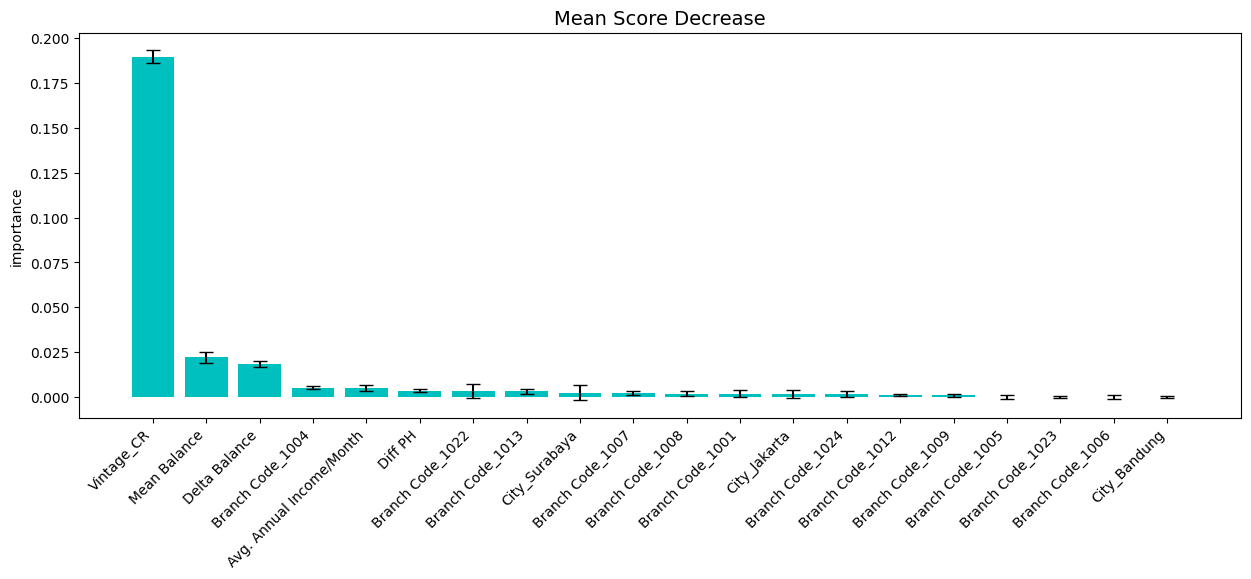

In [107]:
from jcopml.feature_importance import mean_score_decrease
df_imp1 = mean_score_decrease(X1_train, y1_train, grid, plot=True, topk=20)

In [108]:
y2_pred = grid.predict(X2_test)

In [110]:
print('Accuracy:', metrics.accuracy_score(y2_test, y2_pred))
print('Recall:', metrics.recall_score(y2_test, y2_pred))
metrics.completeness_score

Accuracy: 0.2728074041427942
Recall: 0.9966996699669967


<function sklearn.metrics.cluster._supervised.completeness_score(labels_true, labels_pred)>

In [111]:
y2_pred_val = grid.predict(X2_val)
print('Accuracy:', metrics.accuracy_score(y2_val, y2_pred_val))
print('Recall:', metrics.recall_score(y2_val, y2_pred_val))
metrics.completeness_score

Accuracy: 0.3596085173918794
Recall: 0.9929863418235512


<function sklearn.metrics.cluster._supervised.completeness_score(labels_true, labels_pred)>

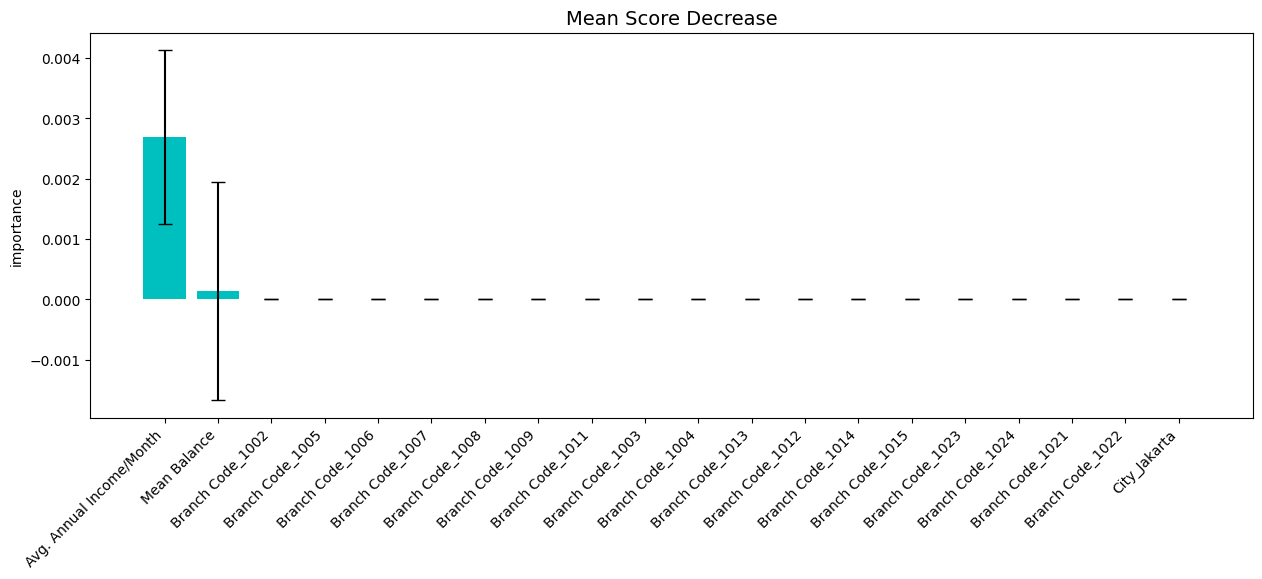

In [112]:
df_imp2 = mean_score_decrease(X2_train, y2_train, grid, plot=True, topk=20)

#2 Gradient Boosting 

In [113]:
y11_pred = GB_Grid1.predict(X1_test)

In [114]:
print('Accuracy:', metrics.accuracy_score(y1_test, y11_pred))
print('Recall:', metrics.recall_score(y1_test, y11_pred))
metrics.completeness_score

Accuracy: 0.7055971793741737
Recall: 0.4735973597359736


<function sklearn.metrics.cluster._supervised.completeness_score(labels_true, labels_pred)>

In [115]:
y11_pred_val = GB_Grid1.predict(X1_val)
print('Accuracy:', metrics.accuracy_score(y1_val, y11_pred_val))
print('Recall:', metrics.recall_score(y1_val, y11_pred_val))
metrics.completeness_score

Accuracy: 0.6429043777278138
Recall: 0.40457733480989294


<function sklearn.metrics.cluster._supervised.completeness_score(labels_true, labels_pred)>

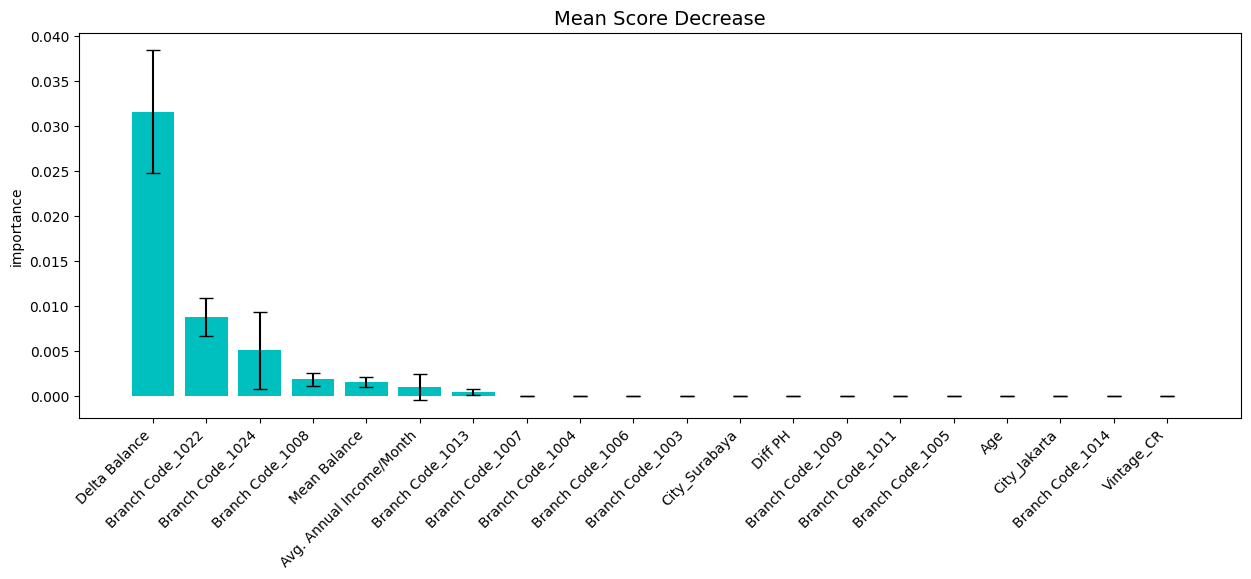

In [116]:
df_imp3 = mean_score_decrease(X2_train, y2_train, GB_Grid1, plot=True, topk=20)

In [117]:
y22_pred = GB_Grid2.predict(X2_test)
print('Accuracy:', metrics.accuracy_score(y2_test, y22_pred))
print('Recall:', metrics.recall_score(y2_test, y22_pred))
metrics.completeness_score

Accuracy: 0.7205817540766858
Recall: 0.49504950495049505


<function sklearn.metrics.cluster._supervised.completeness_score(labels_true, labels_pred)>

In [118]:
y22_pred_val = GB_Grid2.predict(X2_val)
print('Accuracy:', metrics.accuracy_score(y2_val, y22_pred_val))
print('Recall:', metrics.recall_score(y2_val, y22_pred_val))
metrics.completeness_score

Accuracy: 0.6532204734823436
Recall: 0.4138058324104836


<function sklearn.metrics.cluster._supervised.completeness_score(labels_true, labels_pred)>

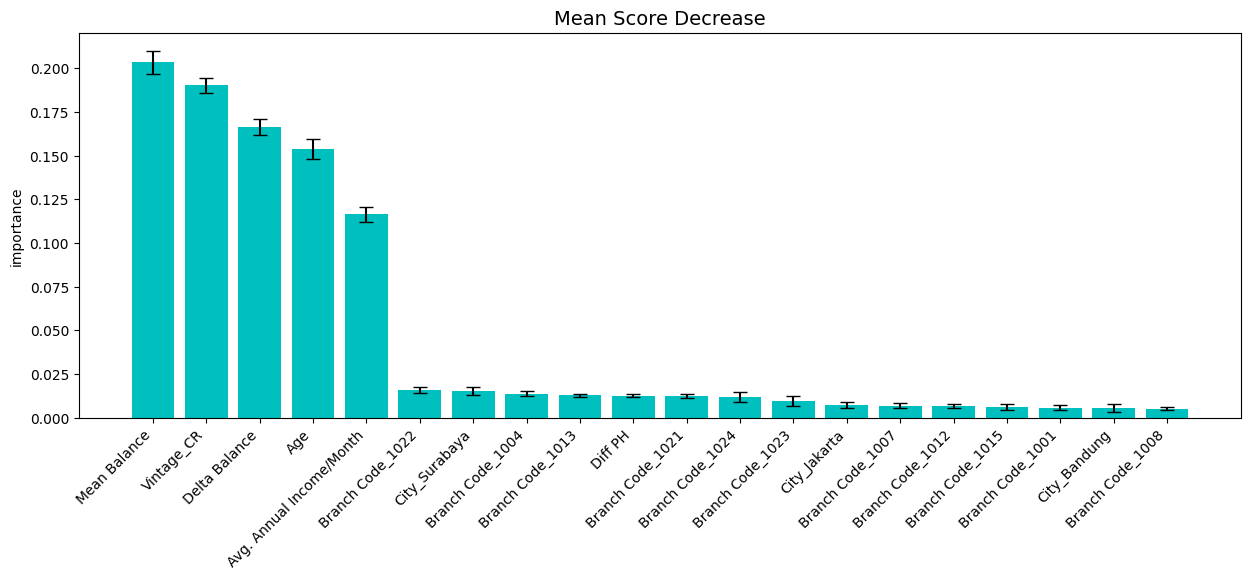

In [119]:
df_imp4 = mean_score_decrease(X2_train, y2_train, GB_Grid2, plot=True, topk=20)

Random Forest

In [120]:
y12_pred =RF_Grid.predict(X1_test)
print('Accuracy:', metrics.accuracy_score(y1_test, y12_pred))
print('Recall:', metrics.recall_score(y1_test, y12_pred))
metrics.completeness_score

Accuracy: 0.8065226972234465
Recall: 0.33003300330033003


<function sklearn.metrics.cluster._supervised.completeness_score(labels_true, labels_pred)>

In [121]:
y12_pred_val =RF_Grid.predict(X1_val)
print('Accuracy:', metrics.accuracy_score(y1_val, y12_pred_val))
print('Recall:', metrics.recall_score(y1_val, y12_pred_val))
metrics.completeness_score

Accuracy: 0.7007009654807566
Recall: 0.3333333333333333


<function sklearn.metrics.cluster._supervised.completeness_score(labels_true, labels_pred)>

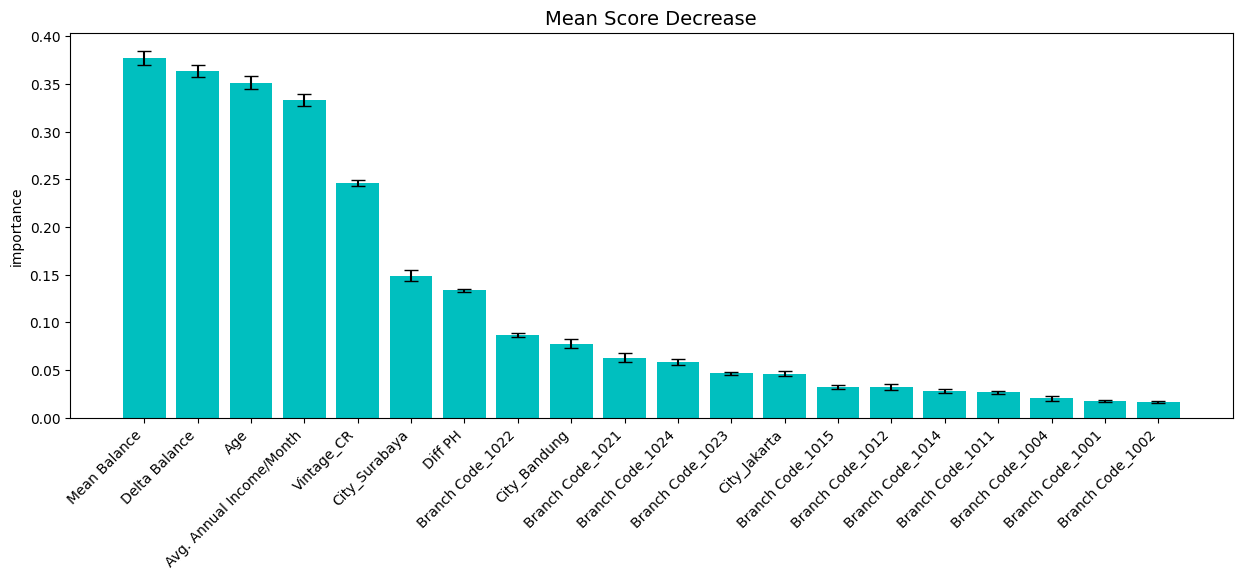

In [122]:
df_imp5 = mean_score_decrease(X1_train, y1_train, RF_Grid, plot=True, topk=20)

In [123]:
y21_pred =RF_Grid2.predict(X2_test)
print('Accuracy:', metrics.accuracy_score(y2_test, y21_pred))
print('Recall:', metrics.recall_score(y2_test, y21_pred))
metrics.completeness_score

Accuracy: 0.8091670339356545
Recall: 0.33663366336633666


<function sklearn.metrics.cluster._supervised.completeness_score(labels_true, labels_pred)>

In [124]:
y21_pred_val =RF_Grid2.predict(X2_val)
print('Accuracy:', metrics.accuracy_score(y2_val, y21_pred_val))
print('Recall:', metrics.recall_score(y2_val, y21_pred_val))
metrics.completeness_score

Accuracy: 0.7020235418595424
Recall: 0.3388704318936877


<function sklearn.metrics.cluster._supervised.completeness_score(labels_true, labels_pred)>

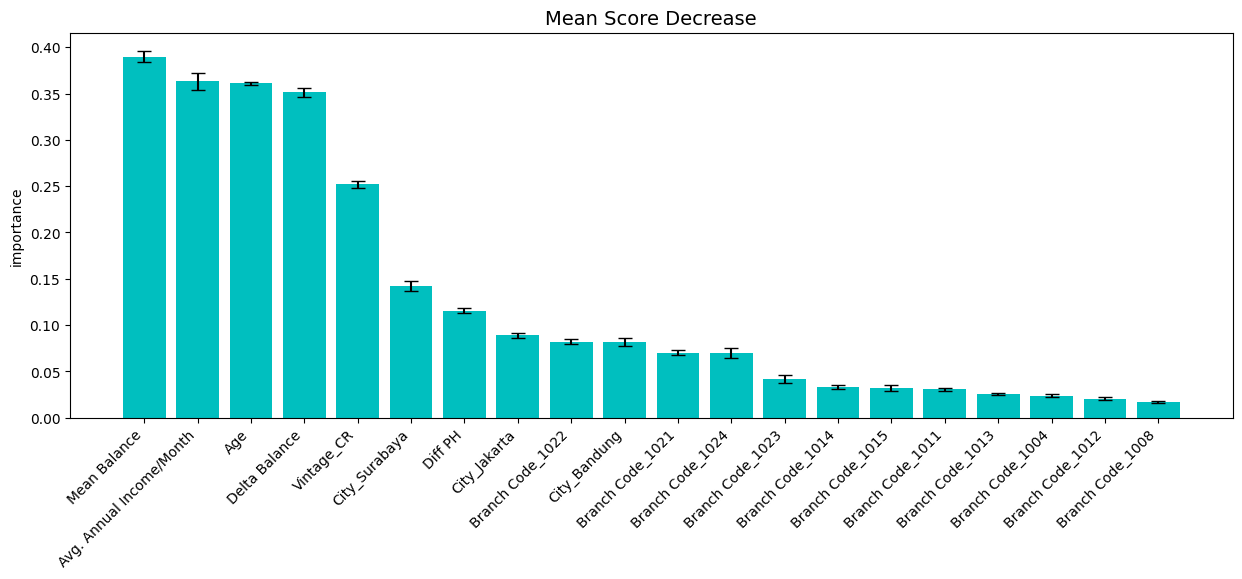

In [125]:
df_imp6 = mean_score_decrease(X2_train, y2_train, RF_Grid2, plot=True, topk=20)

KESIMPULAN
Dari semua modelm beberapa akurasinya di atas 60% dan beberapa di bawah 40% , tetapi nilai recall di bawah 40% dan 70% ke atas untuk nilaiakurasi di bawah 40% . Artinya, masih banyak nasabah yang sebenarnya berpotensi gagal bayar, tetapi diprediksi tidak akan gagal bayar. Dengan demikian, disimpulkan bahwa dalam iterasi pembangunan model kali ini, objektif yang diinginkan masih belum dapat tercapai.

Solusi pengembangan ke depannya:

Memperbanyak sampel (jumlah nasabah dengan asumsi dataset yang tersedia saat ini bukan total populasi nasabah).
Melakukan oversampling terhadap kelas minor (gagal bayar) agar pembangunan model tidak bias.
Memperluas horizon waktu.
Mencoba variasi variabel lainnya (menambah variabel baru, atau membuang variabel yang memiliki nilai importance rendah pada hasil terakhir).
Mencoba memperluas kombinasi hyperparameter dalam pembangunan model.
Mencoba algoritma supervised machine learning lainnya.